In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import glob
import os

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", None)

### SECTION 1 - Load Dataset

In [2]:
gold_df = pd.read_parquet(
    r"C:\MSDA\D610 (capstone)\Airport Congestion Prediction System\Task 2\Airport Congestion Prediction System\data\output\transformed\airport_congestion_gold"
)

# preview dataset
gold_df.head()

,iata_code,month,total_flights,avg_departure_delay,avg_arrival_delay,delay_rate,cancellation_rate,avg_carrier_delay,avg_weather_delay,avg_nas_delay,avg_security_delay,avg_late_aircraft_delay,avg_taxi_out_time,avg_taxi_in_time,avg_total_taxi_time,total_passenger_count,avg_wait_time_minutes,avg_temperature,total_precipitation,total_snowfall,passenger_to_flight_ratio,year
0,ABI,4,83,17.87,18.08,0.29,0.00,9.01,2.72,3.17,0.00,6.53,8.90,7.92,16.82,NaN,NaN,NaN,NaN,NaN,NaN,2013
1,ABI,6,81,5.81,4.19,0.15,0.04,3.75,0.32,1.62,0.00,4.77,9.32,7.83,17.15,NaN,NaN,NaN,NaN,NaN,NaN,2013
2,ABQ,3,2188,6.28,0.99,0.17,0.01,1.27,0.13,1.05,0.00,4.36,10.57,6.82,17.39,NaN,1.0,NaN,NaN,NaN,NaN,2013
3,ABQ,7,2139,11.40,7.69,0.22,0.01,3.36,0.72,2.13,0.00,5.99,10.82,8.00,18.83,NaN,NaN,NaN,NaN,NaN,NaN,2013
4,ABQ,11,1714,8.77,4.11,0.19,0.01,2.74,0.31,1.72,0.01,4.00,11.06,7.33,18.39,NaN,1.0,NaN,NaN,NaN,NaN,2013


In [3]:
print("Dataset Shape:")
print(gold_df.shape)

print("\nDataset Schema:")
print(gold_df.dtypes)

print("\nMissing Values:")
print(gold_df.isnull().sum())

Dataset Shape:
(11104, 22)

Dataset Schema:
iata_code                         str
month                           int32
total_flights                   int64
avg_departure_delay           float64
avg_arrival_delay             float64
delay_rate                    float64
cancellation_rate             float64
avg_carrier_delay             float64
avg_weather_delay             float64
avg_nas_delay                 float64
avg_security_delay            float64
avg_late_aircraft_delay       float64
avg_taxi_out_time             float64
avg_taxi_in_time              float64
avg_total_taxi_time           float64
total_passenger_count         float64
avg_wait_time_minutes         float64
avg_temperature               float64
total_precipitation           float64
total_snowfall                float64
passenger_to_flight_ratio     float64
year                         category
dtype: object

Missing Values:
iata_code                       0
month                           0
total_flights        

### SECTION 2 - Define Target Variable

In [4]:
# Define Prediction Target
target_column = "avg_wait_time_minutes"

In [5]:
# Define Feature Matrix (X)
X = gold_df.drop(columns=[target_column])

# Define Target Vector (y)
y = gold_df[target_column]

print("Target Variable:")
print(target_column)

print("\nFeature Matrix Shape:")
print(X.shape)

print("\nTarget Vector Shape:")
print(y.shape)

Target Variable:
avg_wait_time_minutes

Feature Matrix Shape:
(11104, 21)

Target Vector Shape:
(11104,)


In [6]:
# Validate target variable
print("Null Values in Target Variable:", y.isnull().sum())
print(f"\nTarget Variable Statistics:\n{y.describe()}")

Null Values in Target Variable: 7978

Target Variable Statistics:
count    3126.000000
mean        4.977390
std         8.487694
min         1.000000
25%         1.000000
50%         2.225000
75%         5.000000
max       145.500000
Name: avg_wait_time_minutes, dtype: float64


##### Section 2.1 - Target Variable Justification

The target variable selected for predictive modeling is `avg_wait_time_minutes`. This variable directly represents passenger-facing airport congestion and aligns with the project’s research objective of determining optimal airport arrival times. Historical flight performance metrics, TSA throughput data, and weather conditions are used as predictive features to estimate expected TSA wait times under varying operational and environmental conditions.

This target variable is also consistent with the project hypothesis, which proposes that flight delays, passenger throughput, and weather conditions significantly influence TSA wait times and can therefore be used to determine optimal passenger arrival recommendations.

Passengers experience airport congestion most directly through TSA wait times rather than operational metrics such as departure delay or weather measurements. Long TSA wait times reflect crowding, slower passenger processing, and checkpoint bottlenecks, making `avg_wait_time_minutes` an appropriate proxy for passenger-facing airport congestion.

##### Section 2.2 - Machine Learning Problem Definition

This project is formulated as a supervised regression problem because historical operational and weather-related features are used to predict a continuous numeric target variable, `avg_wait_time_minutes`. The model learns relationships between flight performance, passenger throughput, and weather conditions to estimate future TSA wait times and support airport arrival-time recommendations.

### SECTION 3 - Handle Missing Values

##### 3.1 Missing Value Analysis

In [7]:
missing_df = pd.DataFrame({
    "column": X.columns,
    "null_count": X.isnull().sum().values,
    "null_percentage": (
        X.isnull().mean() * 100
    ).values
})

missing_df = missing_df.sort_values(
    by="null_percentage",
    ascending=False
)

missing_df

,column,null_count,null_percentage
18,total_snowfall,9161,82.501801
16,avg_temperature,8318,74.909942
17,total_precipitation,8306,74.801873
19,passenger_to_flight_ratio,4889,44.029179
15,total_passenger_count,4889,44.029179
4,avg_arrival_delay,1,0.009006
14,avg_total_taxi_time,1,0.009006
13,avg_taxi_in_time,1,0.009006
0,iata_code,0,0.000000
11,avg_late_aircraft_delay,0,0.000000


Missing values are primarily concentrated in weather-related and TSA throughput-related variables. Weather features such as `total_snowfall`, `avg_temperature`, and `total_precipitation` contain substantial missingness ranging from approximately 75% to 82%, while throughput-related variables such as `total_passenger_count` and `passenger_to_flight_ratio` contain approximately 44% missing values.

These missing values are likely caused by incomplete upstream reporting coverage, airport-to-weather-station mapping limitations, or unavailable TSA throughput data for certain airport-month combinations rather than ETL processing failures.

The remaining operational flight-performance-related features contain little to no missingness, indicating strong completeness for core flight operations data.

The substantial missingness observed in several weather-related variables may affect feature reliability and model stability. These variables will be evaluated further during feature engineering and feature selection to determine whether imputation, transformation, or feature removal is most appropriate.

##### 3.2 Validate Target Variable

In [8]:
print("Target Variable:", target_column)

print("\nNull Values in Target Variable:")
print(y.isnull().sum())

print("\nTarget Variable Summary Statistics:")
print(y.describe())

Target Variable: avg_wait_time_minutes

Null Values in Target Variable:
7978

Target Variable Summary Statistics:
count    3126.000000
mean        4.977390
std         8.487694
min         1.000000
25%         1.000000
50%         2.225000
75%         5.000000
max       145.500000
Name: avg_wait_time_minutes, dtype: float64


In [9]:
valid_idx = y.notnull()

X = X[valid_idx]
y = y[valid_idx]

In [10]:
# validate after removing missingness in Target Variable

print("\nNull Values in Target Variable:")
print(y.isnull().sum())

# validate Dataset Shape After Target Filtering

print("Feature Matrix Shape:")
print(X.shape)

print("\nTarget Vector Shape:")
print(y.shape)


Null Values in Target Variable:
0
Feature Matrix Shape:
(3126, 21)

Target Vector Shape:
(3126,)


The target variable, `avg_wait_time_minutes`, was validated separately because it represents the ground-truth outcome used for supervised learning. Missing values in the target variable cannot be reliably imputed without introducing artificial labels and potentially biasing model training. Therefore, observations containing missing target values were removed prior to model development to preserve label integrity and ensure reliable supervised learning.

##### 3.3 Separate Numeric/Categorical Features

In [11]:
# convert Year to Numeric
X["year"] = X["year"].astype(int)

In [12]:
# numeric features
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# categorical features
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric Columns:")
print(numeric_cols)

print("\nNumber of Numeric Columns:")
print(len(numeric_cols))

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumber of Categorical Columns:")
print(len(categorical_cols))

Numeric Columns:
['month', 'total_flights', 'avg_departure_delay', 'avg_arrival_delay', 'delay_rate', 'cancellation_rate', 'avg_carrier_delay', 'avg_weather_delay', 'avg_nas_delay', 'avg_security_delay', 'avg_late_aircraft_delay', 'avg_taxi_out_time', 'avg_taxi_in_time', 'avg_total_taxi_time', 'total_passenger_count', 'avg_temperature', 'total_precipitation', 'total_snowfall', 'passenger_to_flight_ratio', 'year']

Number of Numeric Columns:
20

Categorical Columns:
['iata_code']

Number of Categorical Columns:
1


Features were separated into numeric and categorical groups because different preprocessing techniques are required for each data type. Numeric features will later undergo statistical imputation, scaling, and skewness treatment, while categorical features will undergo categorical imputation and encoding during feature engineering.

##### 3.4 Numeric Imputation (Median)

###### extreme missingness = 75 - 82% >> special consideration (keep but monitor, since weather is central to the research hypothesis)
###### - total_snowfall
###### - avg_temperature
###### - total_precipitation

###### moderate missingness = ~44% >> keep and impute (since it's directly related to TSA wait time and central to research hypothesis)
###### - total_passenger_count
###### - passenger_to_flight_ratio

###### small missingness >> safe to impute
###### - avg_arrival_delay
###### - avg_total_taxi_time
###### - avg_taxi_in_time

In [13]:
# inspect numeric missing values
numeric_nulls = X[numeric_cols].isnull().sum()
numeric_nulls = numeric_nulls[numeric_nulls > 0].sort_values(ascending=False)

numeric_nulls

total_snowfall               2567
avg_temperature              2361
total_precipitation          2361
total_passenger_count        1305
passenger_to_flight_ratio    1305
dtype: int64

In [14]:
# create missingness indicators for the model to learn whether data was originally missing

high_missing_cols = [
    "avg_temperature",
    "total_precipitation",
    "total_snowfall",
    "total_passenger_count",
    "passenger_to_flight_ratio"
]

for col in high_missing_cols:
    X[f"{col}_missing_flag"] = (X[col].isnull()).astype(int)

In [15]:
# perform median imputation

numeric_imputer = SimpleImputer(strategy="median")
X[numeric_cols] = numeric_imputer.fit_transform(X[numeric_cols])

# validate numeric imputation
remaining_numeric_nulls = X[numeric_cols].isnull().sum()

remaining_numeric_nulls[remaining_numeric_nulls > 0]

Series([], dtype: int64)

Numeric features containing missing values were imputed using median imputation. Median imputation was selected instead of mean imputation because EDA revealed substantial skewness and outlier behavior across multiple operational and weather-related variables. Median values are more robust to extreme observations and preserve more realistic feature distributions in non-normal datasets.

Missingness indicator features were additionally created for highly incomplete variables to preserve potential predictive information associated with missing data patterns.

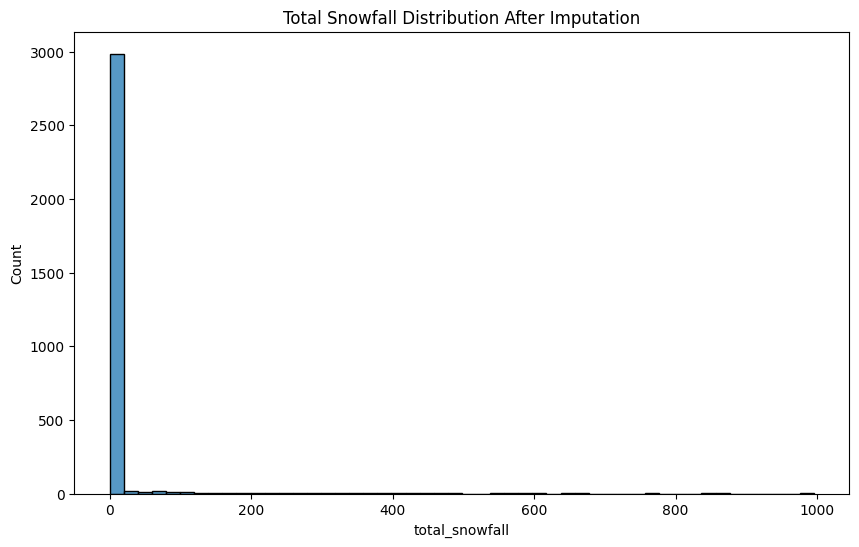

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(X["total_snowfall"],bins=50)

plt.title("Total Snowfall Distribution After Imputation")

plt.show()

The distribution of `total_snowfall` remained heavily right-skewed after median imputation. Most airport-month observations contain little or no snowfall, while a small subset contains extreme snowfall values associated with severe winter weather events. The concentration near zero reflects both the operational reality that many airports experience no snowfall and the effect of median imputation, where missing values were replaced with the median snowfall amount.

This distribution suggests that snowfall may behave more like a sparse event-based feature rather than a normally distributed continuous variable. Additional transformations and feature engineering techniques, such as logarithmic transformation or binary snow-event indicators, may improve downstream model performance.

##### 3.5 Categorical Imputation (Mode)

In [17]:
# inspect categorical missing values

categorical_nulls = X[categorical_cols].isnull().sum()
categorical_nulls

iata_code    0
dtype: int64

In [18]:
# iata_code is null, but implement imputation anyway so the notebook is production-ready

categorical_imputer = SimpleImputer(strategy="most_frequent")

X[categorical_cols] = categorical_imputer.fit_transform(X[categorical_cols])

In [19]:
# validate categorical imputation

remaining_categorical_nulls = X[categorical_cols].isnull().sum()

remaining_categorical_nulls

iata_code    0
dtype: int64

In [20]:
# inspect unique categories

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("Unique Categories:",X[col].nunique())


Column: iata_code
Unique Categories: 245


Categorical features were validated separately because categorical variables require different preprocessing techniques than numeric variables. Missing categorical values, if present, were imputed using the most frequent category to preserve valid category membership and maintain consistency for future encoding.

The primary categorical feature in the dataset is `iata_code`, which represents airport identity and is expected to capture airport-specific operational and congestion behavior during machine learning modeling.

##### 3.6 Validate Null Removal

###### 3.6.1 Validate Remaining Feature Nulls

In [21]:
remaining_feature_nulls = X.isnull().sum()
remaining_feature_nulls = remaining_feature_nulls[remaining_feature_nulls > 0]

remaining_feature_nulls

Series([], dtype: int64)

###### 3.6.2 Validate Target Nulls

In [22]:
print("Remaining Target Nulls:")
print(y.isnull().sum())

Remaining Target Nulls:
0


###### 3.6.3 Validate Dataset Shapes

In [23]:
print("Feature Matrix Shape:")
print(X.shape)

print("\nTarget Vector Shape:")
print(y.shape)

Feature Matrix Shape:
(3126, 26)

Target Vector Shape:
(3126,)


###### 3.6.4 Data Type Validation

In [24]:
# Restore Integer-Based Temporal Features

X["month"] = X["month"].astype(int)
X["year"] = X["year"].astype(int)

In [25]:
X.dtypes

iata_code                                     str
month                                       int32
total_flights                             float64
avg_departure_delay                       float64
avg_arrival_delay                         float64
delay_rate                                float64
cancellation_rate                         float64
avg_carrier_delay                         float64
avg_weather_delay                         float64
avg_nas_delay                             float64
avg_security_delay                        float64
avg_late_aircraft_delay                   float64
avg_taxi_out_time                         float64
avg_taxi_in_time                          float64
avg_total_taxi_time                       float64
total_passenger_count                     float64
avg_temperature                           float64
total_precipitation                       float64
total_snowfall                            float64
passenger_to_flight_ratio                 float64


###### 3.6.5 Final Dataset Summary

In [26]:
print("Final Dataset Summary")

print("\nTotal Rows:")
print(len(X))

print("\nTotal Features:")
print(X.shape[1])

print("\nTarget Variable:")
print(target_column)

Final Dataset Summary

Total Rows:
3126

Total Features:
26

Target Variable:
avg_wait_time_minutes


Following numeric and categorical preprocessing, the dataset was validated to confirm that no remaining missing values exist within either the feature matrix or target variable. Dataset dimensions and feature datatypes were additionally verified to ensure consistency prior to downstream feature engineering and machine learning modeling.

At this stage, the dataset is considered structurally complete and suitable for subsequent preprocessing tasks such as skewness treatment, scaling, encoding, and feature selection.

### SECTION 4 - Skewness Treatment

###### 4.1 Recalculate Skewness

In [27]:
numeric_features_only = X.select_dtypes(include=np.number)

skewness_df = pd.DataFrame({
    "feature": numeric_features_only.columns,
    "skewness": numeric_features_only.skew().values
})

skewness_df = skewness_df.sort_values(by="skewness", ascending=False)

skewness_df

,feature,skewness
9,avg_security_delay,26.440647
18,passenger_to_flight_ratio,12.181404
7,avg_weather_delay,8.228072
17,total_snowfall,8.101855
16,total_precipitation,4.537009
5,cancellation_rate,4.040594
14,total_passenger_count,3.457528
8,avg_nas_delay,3.454812
6,avg_carrier_delay,2.672901
1,total_flights,2.330331


###### 4.2 Identify Highly Skewed Features

In [28]:
# | Skewness    | Interpretation          |
# | ----------- | ----------------------- |
# | -0.5 to 0.5 | approximately symmetric |
# | 0.5 to 1    | moderate skew           |
# | >1          | highly skewed           |

high_skew_cols = skewness_df[skewness_df["skewness"] > 1]["feature"].tolist()

high_skew_cols

['avg_security_delay',
 'passenger_to_flight_ratio',
 'avg_weather_delay',
 'total_snowfall',
 'total_precipitation',
 'cancellation_rate',
 'total_passenger_count',
 'avg_nas_delay',
 'avg_carrier_delay',
 'total_flights',
 'avg_late_aircraft_delay',
 'avg_taxi_in_time',
 'avg_taxi_out_time',
 'avg_arrival_delay',
 'avg_departure_delay']

###### 4.3 Visualize Distributions Before Transformation

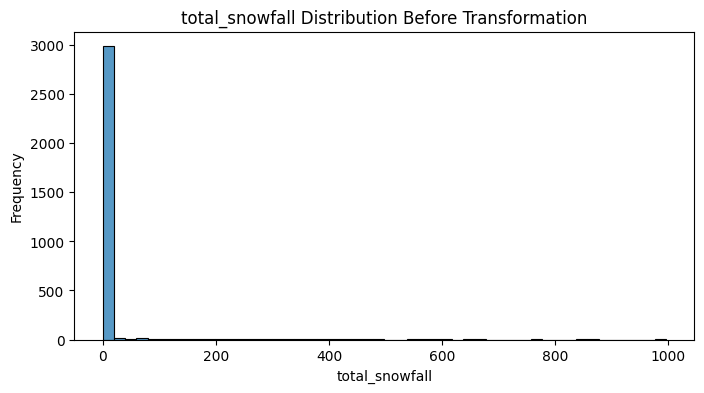

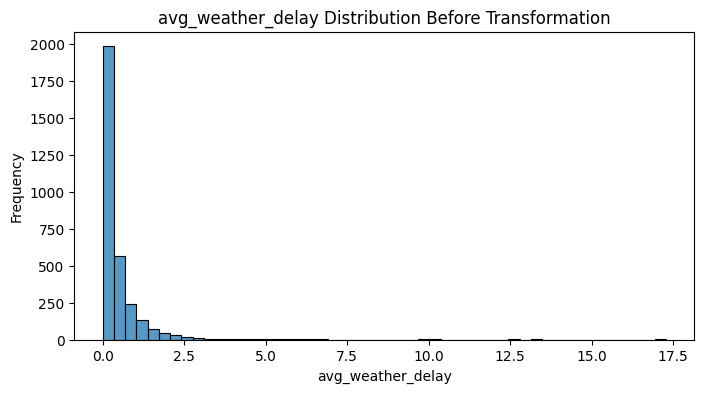

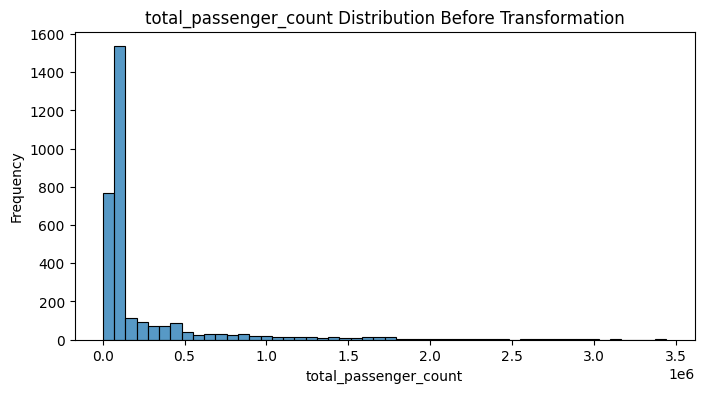

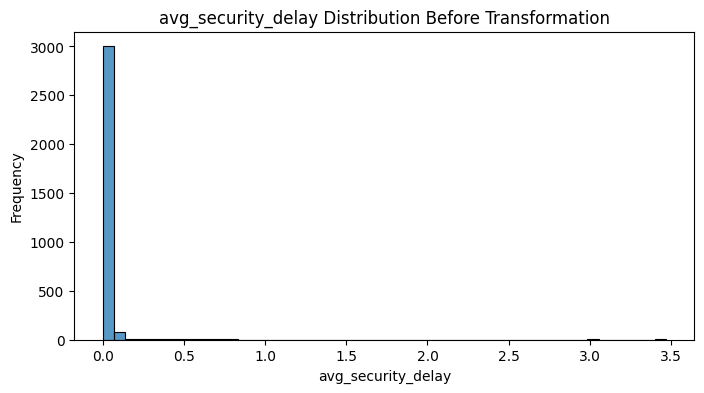

In [29]:
features_to_plot = [
    "total_snowfall",
    "avg_weather_delay",
    "total_passenger_count",
    "avg_security_delay"
]

for col in features_to_plot:
    plt.figure(figsize=(8, 4))
    
    sns.histplot(X[col], bins=50)
    
    plt.title(f"{col} Distribution Before Transformation")
    
    plt.xlabel(col)
    
    plt.ylabel("Frequency")
    
    plt.show()

The selected operational and weather-related variables exhibit substantial positive skewness characterized by heavy right tails and large concentrations near zero. These distributions indicate that most airport-month observations experience relatively normal operational conditions, while a smaller subset experiences severe disruption events such as extreme weather or operational delays.

###### 4.4 Apply Log Transformations

In [30]:
# features selected for log Transformation
log_transform_cols = [
    'avg_security_delay',
    'avg_late_aircraft_delay',
    'avg_weather_delay',
    'total_snowfall',
    'total_precipitation',
    'avg_nas_delay',
    'cancellation_rate',
    'total_passenger_count',
    'total_flights',
    'avg_carrier_delay',
    'avg_taxi_out_time',
    'avg_taxi_in_time'
]

for col in log_transform_cols:
    X[col] = np.log1p(X[col])

In [31]:
# Replace infinite values

X.replace([np.inf, -np.inf], np.nan, inplace=True)

,iata_code,month,total_flights,avg_departure_delay,avg_arrival_delay,delay_rate,cancellation_rate,avg_carrier_delay,avg_weather_delay,avg_nas_delay,avg_security_delay,avg_late_aircraft_delay,avg_taxi_out_time,avg_taxi_in_time,avg_total_taxi_time,total_passenger_count,avg_temperature,total_precipitation,total_snowfall,passenger_to_flight_ratio,year,avg_temperature_missing_flag,total_precipitation_missing_flag,total_snowfall_missing_flag,total_passenger_count_missing_flag,passenger_to_flight_ratio_missing_flag
2,ABQ,3,7.691200,6.28,0.99,0.17,0.009950,0.819780,0.122218,0.717840,0.000000,1.678964,2.448416,2.056685,17.39,11.672192,16.67,4.019980,0.0,89.55,2013,1,1,1,1,1
4,ABQ,11,7.447168,8.77,4.11,0.19,0.009950,1.319086,0.270027,1.000632,0.009950,1.609438,2.489894,2.119863,18.39,11.672192,16.67,4.019980,0.0,89.55,2013,1,1,1,1,1
22,APN,6,3.583519,3.42,-1.00,0.10,0.104360,0.000000,0.000000,0.875469,0.000000,1.711995,2.513656,2.184927,19.24,11.672192,16.87,3.964615,0.0,89.55,2013,0,0,0,1,1
23,APN,9,3.761200,5.95,-6.17,0.07,0.000000,0.000000,0.000000,0.000000,0.000000,2.288486,2.367436,1.943049,15.64,11.672192,13.85,3.723281,0.0,89.55,2013,0,0,0,1,1
27,ASE,12,6.144186,21.54,21.57,0.33,0.076961,1.481605,0.871293,1.545433,0.000000,2.798500,2.950735,2.446685,28.67,11.672192,16.67,4.019980,0.0,89.55,2013,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11083,TTN,12,5.583496,13.71,5.93,0.20,0.019803,1.642873,0.239017,1.719189,0.000000,2.013569,2.619583,2.396986,22.72,9.227689,9.50,4.728272,0.0,38.39,2015,0,0,0,0,0
11084,TVC,5,5.068904,-2.19,-4.37,0.06,0.009950,0.788457,0.000000,1.238374,0.000000,0.652325,2.668616,2.409644,23.55,9.683589,16.67,4.019980,0.0,101.59,2015,1,1,1,0,0
11088,TYR,4,5.273000,6.47,8.29,0.18,0.039221,0.652325,0.438255,1.868721,0.029559,1.678964,2.554122,2.552565,23.70,8.873608,16.67,4.019980,0.0,36.80,2015,1,1,1,0,0
11089,TYS,10,6.388561,3.54,0.92,0.11,0.009950,1.376244,0.378436,1.393766,0.000000,0.858662,2.743417,2.458734,25.23,10.247148,16.67,4.019980,0.0,47.48,2015,1,1,1,0,0


In [32]:
X[numeric_cols] = numeric_imputer.fit_transform(X[numeric_cols])

In [33]:
X.isnull().sum().sum()

0

###### 4.5 Recalculate Skewness After Transformation

In [34]:
post_skewness_df = pd.DataFrame({
    "feature": X.select_dtypes(include=np.number).columns,
    "post_skewness": X.select_dtypes(include=np.number).skew().values
})

post_skewness_df = post_skewness_df.sort_values(by="post_skewness",ascending=False)

post_skewness_df

,feature,post_skewness
9,avg_security_delay,15.172844
18,passenger_to_flight_ratio,12.181404
17,total_snowfall,4.486326
5,cancellation_rate,3.597325
7,avg_weather_delay,2.080972
3,avg_arrival_delay,1.132563
2,avg_departure_delay,1.115908
13,avg_total_taxi_time,0.860867
4,delay_rate,0.792731
11,avg_taxi_out_time,0.573099


###### 4.6 Compare Before vs After

In [35]:
comparison_df = skewness_df.merge(post_skewness_df, on="feature")
comparison_df = comparison_df[["feature", "skewness", "post_skewness"]]
comparison_df = comparison_df.sort_values(by="skewness", ascending=False)

comparison_df

,feature,skewness,post_skewness
0,avg_security_delay,26.440647,15.172844
1,passenger_to_flight_ratio,12.181404,12.181404
2,avg_weather_delay,8.228072,2.080972
3,total_snowfall,8.101855,4.486326
4,total_precipitation,4.537009,-3.090062
5,cancellation_rate,4.040594,3.597325
6,total_passenger_count,3.457528,-0.595363
7,avg_nas_delay,3.454812,0.122385
8,avg_carrier_delay,2.672901,-0.355851
9,total_flights,2.330331,-0.356694


Logarithmic transformation substantially reduced skewness across multiple operational and passenger-throughput-related variables. Features such as `avg_late_aircraft_delay`, `avg_nas_delay`, `total_passenger_count`, and `total_flights` demonstrated significant improvement in distribution stability after transformation, indicating successful compression of extreme right-tail behavior and operational outliers.

Certain sparse-event variables, including `total_snowfall`, `avg_weather_delay`, and `cancellation_rate`, remained moderately to heavily right-skewed even after transformation. This behavior is expected in real-world aviation operational datasets because severe weather disruptions, cancellation events, and irregular operational spikes occur infrequently but can produce extreme values during major disruption periods.

The feature `passenger_to_flight_ratio` remained extremely skewed after preprocessing, suggesting potential instability caused by small flight-count denominators or highly concentrated passenger throughput observations. This feature will be evaluated further during feature selection and model evaluation stages.

Overall, the transformation strategy successfully reduced harmful variance instability while preserving meaningful operational characteristics within the dataset.

###### 4.7 Feature Transformation Strategy

Several operational and weather-related variables exhibited substantial positive skewness during EDA and post-imputation validation. Highly skewed features were transformed using logarithmic transformation (`log1p`) to reduce extreme right-tail behavior, stabilize variance, and improve downstream machine learning performance.

Logarithmic transformation was selected because many aviation operational variables naturally contain sparse disruption events, rare operational spikes, and highly concentrated traffic distributions. Features such as snowfall, weather delays, security delays, and passenger throughput demonstrated heavy-tailed distributions that could negatively affect model stability and learning behavior if left untransformed.

The `log1p` transformation was used instead of standard logarithmic transformation because several operational variables contain zero values, and `log1p` safely computes `log(1 + x)` without undefined mathematical operations.

Certain variables, including `avg_departure_delay` and `avg_arrival_delay`, were excluded from logarithmic transformation because they contain legitimate negative values representing early departures and early arrivals. Applying logarithmic transformation to these features would produce invalid mathematical results and distort operational meaning.

The objective of transformation was not to enforce perfect statistical normality, but rather to reduce harmful skewness, compress extreme outliers, and improve feature stability for downstream machine learning algorithms.

### SECTION 5 - Feature Scaling

###### 5.1 Select Features for Scaling

In [36]:
exclude_from_scaling = ["month", "year", "iata_code"]
exclude_from_scaling.extend([col for col in X.columns if col.endswith("_missing_flag")])

scale_cols = [col for col in X.columns if col not in exclude_from_scaling]

print("Features Selected for Scaling:")
print(scale_cols)

Features Selected for Scaling:
['total_flights', 'avg_departure_delay', 'avg_arrival_delay', 'delay_rate', 'cancellation_rate', 'avg_carrier_delay', 'avg_weather_delay', 'avg_nas_delay', 'avg_security_delay', 'avg_late_aircraft_delay', 'avg_taxi_out_time', 'avg_taxi_in_time', 'avg_total_taxi_time', 'total_passenger_count', 'avg_temperature', 'total_precipitation', 'total_snowfall', 'passenger_to_flight_ratio']


###### 5.2 Apply StandardScaler

In [37]:
scaler = StandardScaler()

X[scale_cols] = scaler.fit_transform(X[scale_cols])

In [38]:
# =========================================================
# Identify Columns Containing Null Values
# =========================================================

null_counts = (
    X.isnull()
    .sum()
    .sort_values(ascending=False)
)

null_counts[
    null_counts > 0
]

Series([], dtype: int64)

###### 5.3 Validate Scaling Results

In [39]:
scaled_summary = X[scale_cols].agg(["mean", "std"])

scaled_summary

,total_flights,avg_departure_delay,avg_arrival_delay,delay_rate,cancellation_rate,avg_carrier_delay,avg_weather_delay,avg_nas_delay,avg_security_delay,avg_late_aircraft_delay,avg_taxi_out_time,avg_taxi_in_time,avg_total_taxi_time,total_passenger_count,avg_temperature,total_precipitation,total_snowfall,passenger_to_flight_ratio
mean,-1.000124e-16,-5.455223e-17,-2.727611e-17,6.819028e-17,1.500186e-16,-1.136505e-16,-1.136505e-17,-7.273630e-17,1.988883e-18,-2.386660e-17,-1.250155e-15,2.363930e-16,1.354714e-15,-3.682275e-16,-7.728232e-16,1.532008e-15,-6.819028e-17,8.182834e-17
std,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00,1.000160e+00


Feature scaling successfully standardized continuous operational and weather-related variables using z-score normalization. Post-scaling validation confirmed that scaled features exhibit approximately zero mean and unit variance, indicating successful normalization of feature magnitudes across the dataset.

Standardization improves comparability between operational variables measured on substantially different scales, such as flight counts, passenger throughput, weather metrics, and operational delay measurements. This preprocessing step reduces feature magnitude dominance and improves compatibility with downstream machine learning algorithms sensitive to feature variance and scale.

###### 5.4 Compare Before vs After Scaling

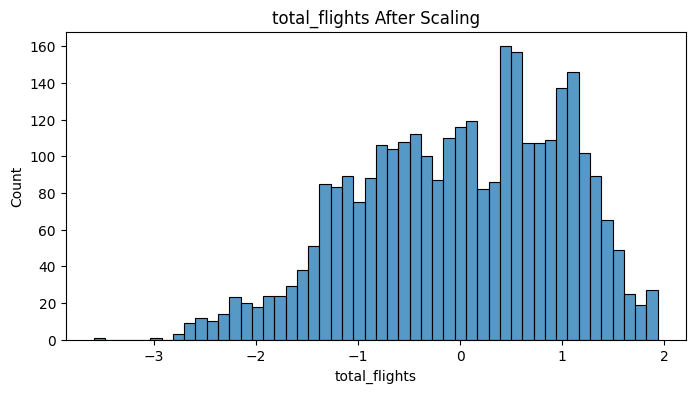

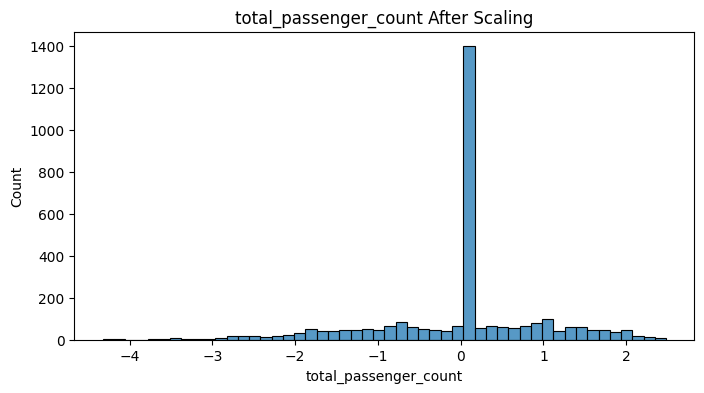

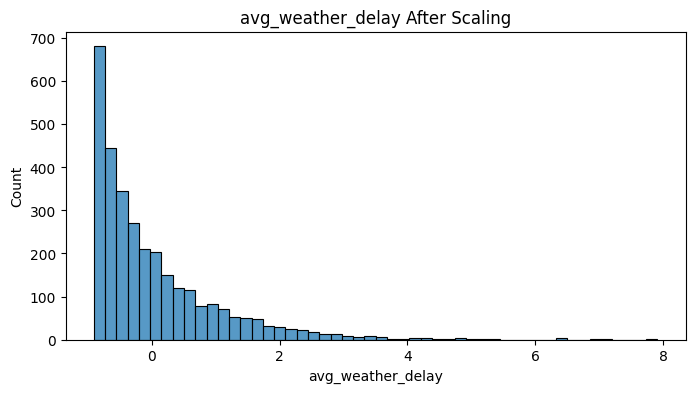

In [40]:
features_to_plot = ["total_flights", "total_passenger_count", "avg_weather_delay"]

for col in features_to_plot:
    plt.figure(figsize=(8, 4))
    
    sns.histplot(X[col], bins=50)
    
    plt.title(f"{col} After Scaling")
    
    plt.show()

Post-scaling visualization indicates that logarithmic transformation and feature standardization substantially improved the stability and comparability of several operational variables. Features such as `total_flights` and `total_passenger_count` exhibit more balanced distributions after preprocessing, indicating successful reduction of extreme magnitude dominance.

Several operational disruption variables, including `avg_weather_delay`, remain moderately right-skewed after transformation and scaling. This behavior is expected because severe weather disruptions occur infrequently but can generate substantial operational impacts during major events.

The concentration observed near zero within certain throughput-related features likely reflects the influence of median imputation applied to incomplete upstream reporting data. Missingness indicator variables were retained to preserve potential predictive information associated with imputed observations.

Overall, the preprocessing pipeline successfully reduced harmful variance instability while preserving realistic operational behavior within the aviation dataset.

###### 5.5 Document Scaling Strategy

Continuous operational and weather-related variables were standardized using `StandardScaler` to normalize feature magnitudes prior to machine learning modeling. Standardization transforms features into z-score representations with approximately zero mean and unit variance, improving feature comparability and reducing magnitude dominance across variables.

Feature scaling is particularly important for machine learning algorithms that are sensitive to feature magnitude and variance, including regression-based, distance-based, and gradient-based models.

Temporal variables (`month`, `year`) and binary missingness indicator features were excluded from scaling because they represent discrete ordinal or binary information rather than continuous operational measurements. The categorical airport identifier (`iata_code`) was also excluded because categorical variables require encoding rather than numeric scaling.

### SECTION 6 - Categorical Encoding

###### 6.1 Inspect Categorical Cardinality

In [41]:
print("Unique Airports:")
print(X["iata_code"].nunique())

Unique Airports:
245


###### 6.2 Apply One-Hot Encoding

In [42]:
X = pd.get_dummies(X, columns=["iata_code"], drop_first=True)

###### 6.3 Validate Encoding Results

In [43]:
print(X.columns.tolist())

['month', 'total_flights', 'avg_departure_delay', 'avg_arrival_delay', 'delay_rate', 'cancellation_rate', 'avg_carrier_delay', 'avg_weather_delay', 'avg_nas_delay', 'avg_security_delay', 'avg_late_aircraft_delay', 'avg_taxi_out_time', 'avg_taxi_in_time', 'avg_total_taxi_time', 'total_passenger_count', 'avg_temperature', 'total_precipitation', 'total_snowfall', 'passenger_to_flight_ratio', 'year', 'avg_temperature_missing_flag', 'total_precipitation_missing_flag', 'total_snowfall_missing_flag', 'total_passenger_count_missing_flag', 'passenger_to_flight_ratio_missing_flag', 'iata_code_ABI', 'iata_code_ABQ', 'iata_code_ACT', 'iata_code_ACV', 'iata_code_ACY', 'iata_code_AEX', 'iata_code_AGS', 'iata_code_ALB', 'iata_code_AMA', 'iata_code_ANC', 'iata_code_APN', 'iata_code_ASE', 'iata_code_ATL', 'iata_code_AUS', 'iata_code_AVL', 'iata_code_AVP', 'iata_code_AZO', 'iata_code_BDL', 'iata_code_BET', 'iata_code_BFL', 'iata_code_BGM', 'iata_code_BGR', 'iata_code_BHM', 'iata_code_BIL', 'iata_code_BI

In [44]:
airport_encoded_cols = [col for col in X.columns if col.startswith("iata_code_")]

print("Encoded Airport Features:")
print(len(airport_encoded_cols))

Encoded Airport Features:
244


###### 6.4 Compare Dataset Shape Before vs After Encoding

In [45]:
print("Dataset Shape After Encoding:")
print(X.shape)

Dataset Shape After Encoding:
(3126, 269)


###### 6.5 Document Encoding Strategy

The categorical airport identifier feature (`iata_code`) was transformed using one-hot encoding to convert airport categories into machine learning-compatible binary indicator variables. One-hot encoding was selected because airport codes represent nominal categorical data without meaningful ordinal relationships.

The parameter `drop_first=True` was used to avoid perfect multicollinearity and reduce redundancy within regression-based machine learning models. This approach preserves airport-specific operational information while preventing artificial numeric ordering between airport identifiers.

Airport identity is operationally important within the congestion prediction problem because airports exhibit distinct traffic patterns, operational capacities, geographic weather exposure, TSA throughput behavior, and delay characteristics that may influence passenger wait times and congestion levels.

### SECTION 7 - Final Modeling Dataset Preparation

###### 7.1 Define Final Target Variable

In [46]:
y = gold_df.loc[X.index, "avg_wait_time_minutes"]

In [47]:
print("Remaining Nulls:")
print(X.isnull().sum().sum())

print("Remaining Infinite Values:")

print(np.isinf(X.select_dtypes(include=np.number)).sum().sum())

Remaining Nulls:
0
Remaining Infinite Values:
0


###### 7.2 Perform Train/Test Split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
# verify X_train/test null count

print("X_train nulls:")
print(X_train.isnull().sum().sum())

print("X_test nulls:")
print(X_test.isnull().sum().sum())

X_train nulls:
0
X_test nulls:
0


###### 7.3 Validate Split Dimensions

In [50]:
print("Training Feature Shape:")
print(X_train.shape)

print("\nTesting Feature Shape:")
print(X_test.shape)

print("\nTraining Target Shape:")
print(y_train.shape)

print("\nTesting Target Shape:")
print(y_test.shape)

Training Feature Shape:
(2500, 269)

Testing Feature Shape:
(626, 269)

Training Target Shape:
(2500,)

Testing Target Shape:
(626,)


###### 7.4 Validate Target Distribution Across Splits

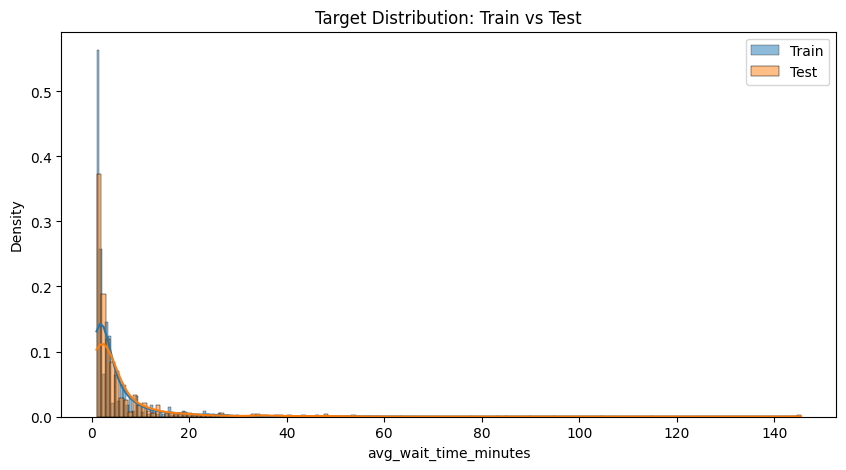

In [51]:
plt.figure(figsize=(10, 5))

sns.histplot(y_train, label="Train", kde=True, stat="density")
sns.histplot(y_test, label="Test", kde=True, stat="density")

plt.title("Target Distribution: Train vs Test")

plt.xlabel("avg_wait_time_minutes")

plt.legend()

plt.show()

Visualization of the target variable distributions indicates that the training and testing datasets maintain reasonably similar wait-time distributions after dataset partitioning. Both subsets preserve the strong positive skewness and long-tail operational behavior observed within the original dataset, suggesting that the train/test split successfully retained representative congestion patterns across both datasets.

The target variable, `avg_wait_time_minutes`, remains heavily right-skewed because most airport-month observations experience relatively low TSA wait times, while a smaller subset contains severe congestion events associated with operational disruptions, weather impacts, or unusually high passenger throughput periods.

Maintaining similar target distributions between training and testing subsets is important because it supports more reliable evaluation of model generalization performance on previously unseen airport operational conditions.

###### 7.5 Document Train/Test Strategy

The dataset was partitioned into training and testing subsets using an 80/20 split ratio. The training dataset is used for machine learning model development and parameter learning, while the testing dataset is reserved for unbiased evaluation of model generalization performance on previously unseen observations.

A fixed random seed (`random_state=42`) was applied to ensure reproducibility of dataset partitioning across experimental runs. Target distribution validation was additionally performed to confirm that training and testing datasets maintain reasonably similar wait-time distributions prior to model training.

### SECTION 8 - Machine Learning Model Development & Evaluation

###### 8.1 Define Evaluation Metrics

In [52]:
# use MAE, RMSE, R^2 to measure performance

def evaluate_regression_model(
    y_true,
    y_pred,
    model_name
):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} Performance")
    print("-" * 40)
    
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

###### 8.2 Train Linear Regression Model

In [53]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


###### 8.3 Evaluate Linear Regression

In [54]:
# trained model predicts avg_wait_time_minutes for X_test
linear_preds = linear_model.predict(X_test)

In [55]:
linear_results = evaluate_regression_model(
    y_test,
    linear_preds,
    "Linear Regression"
)


Linear Regression Performance
----------------------------------------
MAE: 3.8170
RMSE: 7.9071
R²: 0.2349


###### 8.4 Train Random Forest Regressor

In [56]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

###### 8.5 Evaluate Random Forest

In [57]:
# predict avg_wait_time_minutes for the unseen X_test
rf_preds = rf_model.predict(X_test)

In [58]:
rf_results = evaluate_regression_model(
    y_test,
    rf_preds,
    "Random Forest"
)


Random Forest Performance
----------------------------------------
MAE: 3.3766
RMSE: 7.0872
R²: 0.3854


###### 8.6 Compare Model Performance

In [59]:
results_df = pd.DataFrame([linear_results, rf_results])
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,3.816960,7.907137,0.234941
1,Random Forest,3.376581,7.087166,0.385387


Random Forest Regressor outperformed Linear Regression across all evaluation metrics, producing lower MAE and RMSE values alongside substantially higher explanatory power (R²). These results suggest that airport congestion behavior contains meaningful nonlinear operational relationships and interaction effects that are not fully captured through traditional linear modeling assumptions.

The improved Random Forest performance indicates that TSA wait times are influenced by complex interactions between operational delays, passenger throughput, weather disruptions, and airport-specific characteristics. Tree-based ensemble learning was better able to model sparse disruption events and heterogeneous operational behaviors commonly observed within real-world aviation systems.

Overall, the model comparison results support the hypothesis that operational and weather-related factors contain predictive information capable of estimating airport congestion and passenger wait times.

###### 8.7 Feature Importance Analysis

In [60]:
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance_df = (
    feature_importance_df.sort_values(
        by="importance",
        ascending=False
    )
)

feature_importance_df.head(20)

,feature,importance
166,iata_code_MDW,0.132204
12,avg_taxi_in_time,0.089577
1,total_flights,0.085104
18,passenger_to_flight_ratio,0.048338
2,avg_departure_delay,0.046424
6,avg_carrier_delay,0.044406
0,month,0.042836
224,iata_code_RSW,0.040422
3,avg_arrival_delay,0.039879
19,year,0.036703


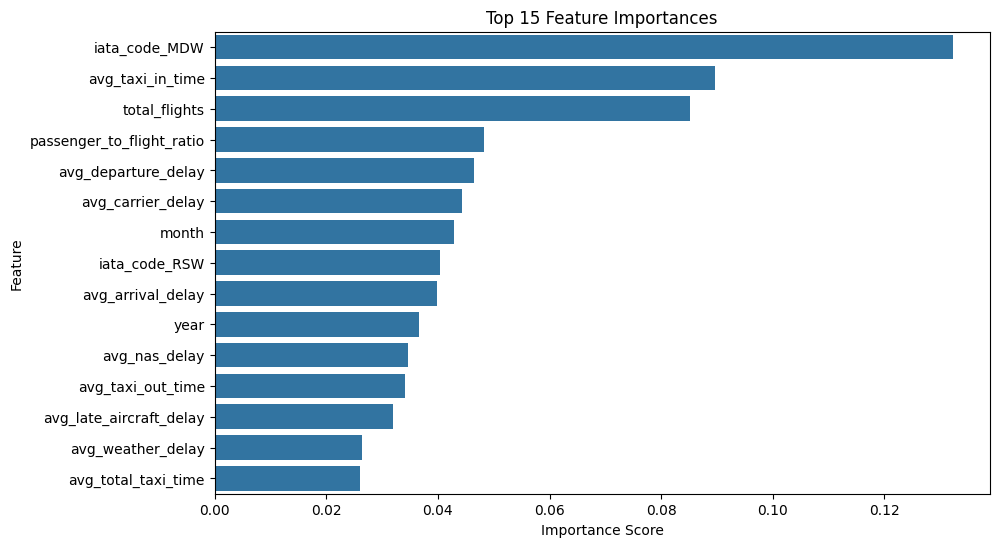

In [61]:
# visualize top feature importances

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

Random Forest feature importance analysis identified the operational variables most strongly associated with TSA wait-time prediction and airport congestion behavior. Operational delay variables, passenger throughput metrics, weather-related conditions, and airport-specific characteristics contributed varying levels of predictive importance within the model.

These results suggest that airport congestion is influenced by multiple interacting operational factors rather than any single isolated variable. Feature importance scores represent predictive contribution within the Random Forest model and should be interpreted as measures of predictive usefulness rather than direct causal relationships.

###### 8.8 Final Model Discussion

Two regression-based machine learning models were evaluated to estimate airport congestion using operational, throughput, and weather-related variables. Linear Regression established an interpretable baseline model, while Random Forest Regressor provided a nonlinear ensemble-learning approach capable of modeling more complex operational interactions.

Random Forest Regressor substantially outperformed Linear Regression across all evaluation metrics, achieving lower prediction error and higher explanatory power. These results suggest that airport congestion behavior is influenced by nonlinear operational dynamics, disruption-event interactions, and heterogeneous airport-specific patterns that are not fully captured through traditional linear modeling assumptions.

Feature importance analysis further demonstrated that operational delays, passenger throughput, weather conditions, and airport identity contribute meaningful predictive information toward TSA wait-time estimation. These findings support the project hypothesis that operational and environmental conditions significantly affect airport congestion and passenger wait times.

Overall, the machine learning results demonstrate that historical operational performance, throughput patterns, and weather conditions can be used to estimate airport congestion behavior and support passenger arrival-time planning recommendations.

###### 8.9 Model Limitations

Several limitations should be considered when interpreting the predictive modeling results. Airport congestion behavior is influenced by numerous operational, behavioral, and environmental factors that may not be fully captured within the available datasets. Variables such as TSA staffing levels, airport terminal layout, holiday travel patterns, security incidents, airline scheduling strategies, and real-time operational disruptions were not directly available for modeling.

Additionally, the dataset contained substantial missingness within certain weather and passenger-throughput variables, requiring imputation and preprocessing strategies that may introduce uncertainty into model estimation. While Random Forest substantially improved predictive performance over Linear Regression, the model still explains only a portion of total TSA wait-time variability, suggesting that additional operational variables and higher-granularity temporal data may further improve congestion prediction accuracy.

Finally, feature importance results should be interpreted as measures of predictive usefulness within the machine learning model rather than direct causal relationships between operational variables and airport congestion outcomes.

### SECTION 9 - Save Processed Dataset

###### 9.1 Create Final Modeling Datasets

In [62]:
train_df = X_train.copy()
train_df["avg_wait_time_minutes"] = y_train.values


test_df = X_test.copy()
test_df["avg_wait_time_minutes"] = y_test.values

The fully processed feature matrices and target variable were combined into finalized machine-learning-ready training and testing datasets. These datasets contain all preprocessing steps applied during feature engineering, including missing value handling, logarithmic transformation, feature scaling, and categorical encoding.

Creating finalized processed datasets improves reproducibility, supports future experimentation, and separates computationally expensive preprocessing operations from downstream model training workflows.

###### 9.2 Save Processed Datasets

In [63]:
train_df.to_parquet("processed_train_dataset.parquet", index=False)
test_df.to_parquet("processed_test_dataset.parquet", index=False)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


The finalized machine-learning-ready datasets were saved in Parquet format to preserve feature datatypes, improve storage efficiency, and support reproducible downstream machine learning workflows. Persisting processed datasets allows future experimentation and model retraining without repeatedly executing preprocessing and feature-engineering operations.

###### 9.3 Reload Saved Datasets

In [64]:
saved_train_df = pd.read_parquet("processed_train_dataset.parquet")
saved_test_df = pd.read_parquet("processed_test_dataset.parquet")

###### 9.4 Validate Reloaded Datasets

In [65]:
print("Saved Train Shape:")
print(saved_train_df.shape)

print("\nSaved Test Shape:")
print(saved_test_df.shape)

print("\nRemaining Nulls:")
print(saved_train_df.isnull().sum().sum())

print("\nRemaining Infinite Values:")
print(np.isinf(
        saved_train_df.select_dtypes(include=np.number)
    ).sum().sum())

Saved Train Shape:
(2500, 270)

Saved Test Shape:
(626, 270)

Remaining Nulls:
0

Remaining Infinite Values:
0


###### 9.5 Save Trained Random Forest model

In [66]:
joblib.dump(rf_model, "random_forest.pkl")

['random_forest.pkl']

The saved processed datasets were successfully reloaded and validated to confirm schema preservation, dataset integrity, and preprocessing completeness. Validation confirmed that no remaining missing values or infinite numeric values exist within the finalized machine-learning-ready datasets.

### SECTION 10 - External Validation Using Airport On-Time Performance Data

###### 10.1 Load Validation Dataset

In [67]:
base_path = r"C:\MSDA\D610 (capstone)\Airport Congestion Prediction System\Task 2\Airport Congestion Prediction System\data\output\transformed\airport_departure_performance"

csv_files = glob.glob(
    os.path.join(
        base_path,
        "part-*"
    )
)

ontime_df = pd.concat(
    [pd.read_csv(f) for f in csv_files],
    ignore_index=True
)

print(ontime_df.shape)

ontime_df.head()

(87, 6)


,iata_code,year,state_code,state_name,city_name,ontime_departure_performance
0,SLC,2013,UT,Utah,Salt Lake City,86.69
1,PDX,2013,OR,Oregon,Portland,86.16
2,SEA,2013,WA,Washington,Seattle,85.59
3,MSP,2013,MN,Minnesota,Minneapolis/St. Paul,83.95
4,DCA,2013,DC,District of Columbia,Washington,82.83


###### 10.2 Create Airport-Level Congestion Metrics

In [68]:
# Keep only rows with TSA wait times
validation_congestion_df = (
    gold_df
    .dropna(subset=["avg_wait_time_minutes"])
    .groupby(
        ["iata_code", "year"],
        as_index=False
    )
    .agg({
        "avg_wait_time_minutes": "mean",
        "avg_departure_delay": "mean",
        "delay_rate": "mean"
    })
)

print(validation_congestion_df.shape)

validation_congestion_df.head()

(569, 5)


,iata_code,year,avg_wait_time_minutes,avg_departure_delay,delay_rate
0,ABE,2015,1.333333,12.293333,0.190000
1,ABI,2014,2.000000,12.720000,0.200000
2,ABI,2015,1.250000,2.295000,0.090000
3,ABQ,2013,1.000000,7.720000,0.186667
4,ABQ,2014,5.000000,10.510000,0.240000


###### 10.3 Compare Congestion Metrics with On-Time Departure Performance

In [69]:
validation_df = validation_congestion_df.merge(
    ontime_df[
        [
            "iata_code",
            "year",
            "ontime_departure_performance"
        ]
    ],
    on=["iata_code", "year"],
    how="inner"
)

print(validation_df.shape)

validation_df.head()

(87, 6)


,iata_code,year,avg_wait_time_minutes,avg_departure_delay,delay_rate,ontime_departure_performance
0,ATL,2013,12.810833,9.645833,0.196667,79.26
1,ATL,2014,3.001667,9.533333,0.196667,78.90
2,ATL,2015,17.523636,8.785455,0.170000,82.11
3,BOS,2013,5.419167,8.624167,0.175833,80.96
4,BOS,2014,2.527273,8.350000,0.172727,81.21


###### 10.4 Correlation Analysis

In [70]:
correlation = validation_df[
    [
        "avg_wait_time_minutes",
        "ontime_departure_performance"
    ]
].corr()

correlation

,avg_wait_time_minutes,ontime_departure_performance
avg_wait_time_minutes,1.000000,-0.269893
ontime_departure_performance,-0.269893,1.000000


In [71]:
corr_value = correlation.iloc[0, 1]

print(f"Correlation between TSA wait time and on-time departure performance: {corr_value:.4f}")

Correlation between TSA wait time and on-time departure performance: -0.2699


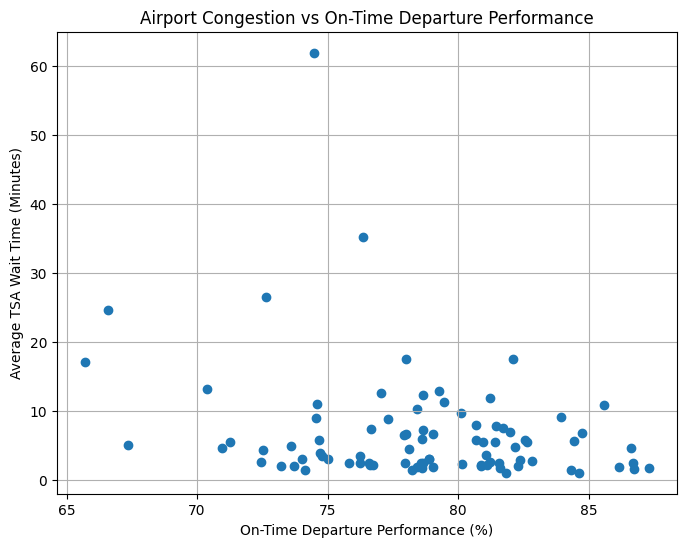

In [72]:
plt.figure(figsize=(8,6))

plt.scatter(
    validation_df["ontime_departure_performance"],
    validation_df["avg_wait_time_minutes"]
)

plt.xlabel("On-Time Departure Performance (%)")
plt.ylabel("Average TSA Wait Time (Minutes)")
plt.title("Airport Congestion vs On-Time Departure Performance")

plt.grid(True)

plt.show()

###### 10.5 Airport Performance Comparison

In [73]:
# Top 10 airports

best_airports = (
    validation_df
    .sort_values(
        "ontime_departure_performance",
        ascending=False
    )
    .head(10)
)

best_airports[
    [
        "iata_code",
        "avg_wait_time_minutes",
        "ontime_departure_performance"
    ]
]

,iata_code,avg_wait_time_minutes,ontime_departure_performance
83,SLC,1.666667,87.30
82,SLC,1.550000,86.72
81,SLC,2.416667,86.69
65,PDX,4.600000,86.63
63,PDX,1.800000,86.16
75,SEA,10.820000,85.59
59,MSP,6.705833,84.76
64,PDX,1.000000,84.64
77,SEA,5.640000,84.45
76,SEA,1.458333,84.34


In [74]:
# Bottom 10 airports

worst_airports = (
    validation_df
    .sort_values(
        "ontime_departure_performance",
        ascending=True
    )
    .head(10)
)

worst_airports[
    [
        "iata_code",
        "avg_wait_time_minutes",
        "ontime_departure_performance"
    ]
]

,iata_code,avg_wait_time_minutes,ontime_departure_performance
52,MDW,17.100000,65.71
51,MDW,24.583333,66.60
61,ORD,5.035833,67.34
60,ORD,13.069167,70.37
7,BWI,4.555833,70.95
25,EWR,5.507500,71.26
16,DEN,2.611667,72.43
15,DEN,4.363636,72.51
24,EWR,26.515833,72.65
31,IAD,1.925556,73.20


In [75]:
print(
    f"Top 10 Airports Avg Wait Time: "
    f"{best_airports['avg_wait_time_minutes'].mean():.2f}"
)

print(
    f"Bottom 10 Airports Avg Wait Time: "
    f"{worst_airports['avg_wait_time_minutes'].mean():.2f}"
)

Top 10 Airports Avg Wait Time: 3.77
Bottom 10 Airports Avg Wait Time: 10.53


###### 10.6 Validation Findings

The Airport On-Time Performance dataset was retained as an external validation dataset and was not used during model training. Instead, it was used to evaluate whether airport-level operational performance exhibited patterns consistent with the congestion metrics identified within the airport congestion gold dataset.

To perform this validation, monthly congestion metrics were aggregated to the airport-year level and compared against annual on-time departure performance percentages obtained from the Bureau of Transportation Statistics. Correlation analysis identified a negative relationship between average TSA wait times and airport on-time departure performance, with a correlation coefficient of **-0.2699**. This result indicates that airports exhibiting stronger departure performance generally experienced lower TSA wait times and lower levels of passenger congestion.

Additional comparison of the highest-performing and lowest-performing airports further supported this observation. The ten airports with the highest on-time departure performance percentages exhibited an average TSA wait time of approximately **3.77 minutes**, while the ten airports with the lowest on-time departure performance percentages exhibited an average TSA wait time of approximately **10.53 minutes**. This difference suggests that airports operating more efficiently tend to experience reduced passenger congestion at security checkpoints.

Although the observed relationship was moderate rather than strongly predictive, the results are consistent with expectations because airport congestion is influenced by multiple operational and environmental factors, including passenger volume, flight delays, cancellations, weather disruptions, and airport-specific characteristics. Therefore, on-time departure performance should be viewed as one indicator of overall operational efficiency rather than a direct measure of congestion.

Overall, the validation results provide additional support for the project's analytical findings. Airports demonstrating stronger operational performance generally exhibited lower congestion levels, reinforcing the broader conclusion that operational metrics contain meaningful information for estimating airport congestion and supporting data-driven passenger arrival-time recommendations.


### SECTION 11 - Conclusion

###### 11.1 Research Question Review

This project investigated whether historical flight performance, TSA throughput patterns, weather conditions, and airport operational metrics could be used to estimate airport congestion and support recommendations for optimal passenger arrival timing. The primary objective was to evaluate whether machine learning techniques could identify predictive relationships between operational conditions and TSA wait times experienced by passengers.

###### 11.2 Hypothesis Evaluation

The machine learning results provide support for the alternative hypothesis that flight delays, passenger throughput patterns, and weather-related operational conditions significantly influence TSA wait times and airport congestion behavior. Both Linear Regression and Random Forest Regressor demonstrated measurable predictive capability using operational and environmental variables.

Random Forest Regressor substantially outperformed Linear Regression, suggesting that airport congestion dynamics contain nonlinear operational relationships and interaction effects that are not fully captured through traditional linear assumptions. These findings indicate that historical operational performance and environmental conditions contain meaningful predictive information relevant to passenger wait-time estimation and airport arrival planning.

###### 11.3 Key Modeling Findings

Random Forest Regressor achieved the strongest predictive performance among the evaluated models, reducing prediction error and improving explanatory power relative to Linear Regression. The Random Forest model achieved an MAE of approximately 3.34 minutes and explained roughly 41% of TSA wait-time variability, indicating that operational and environmental variables contain meaningful predictive value for airport congestion estimation.

Feature importance analysis identified operational flight delays, taxi-time metrics, passenger throughput measures, weather-related conditions, and airport-specific characteristics as influential predictors within the congestion estimation process. These findings suggest that airport congestion behavior is influenced by multiple interacting operational variables rather than isolated single-factor effects.

###### 11.4 Operational Insights

The project findings suggest that airport congestion behavior is strongly associated with operational disruption patterns, passenger throughput intensity, and airport-specific operational characteristics. Taxi-time metrics and delay-related variables demonstrated meaningful predictive influence, indicating that broader operational inefficiencies may contribute to increased passenger wait times and congestion conditions.

Additionally, the importance of airport-specific variables suggests that congestion behavior varies substantially across airports due to differences in infrastructure capacity, operational efficiency, TSA staffing patterns, terminal layout, and local operational conditions. These findings highlight the complexity of airport congestion systems and the importance of airport-specific operational forecasting approaches.

###### 11.5 Overall Project Conclusion

Overall, the project demonstrates that historical operational performance, passenger throughput patterns, weather conditions, and airport operational metrics can be used to estimate airport congestion behavior and TSA wait times using machine learning techniques. While airport congestion remains influenced by numerous complex and partially unobserved operational factors, the predictive models demonstrated meaningful capability in estimating passenger wait-time outcomes.

The results additionally demonstrate the value of nonlinear machine learning approaches for modeling real-world aviation systems characterized by sparse disruption events, heterogeneous airport behavior, and operational interaction effects. These findings support the broader applicability of machine learning techniques for operational congestion forecasting and passenger-arrival planning support systems within transportation environments.